# Visibility graph

최근에 문득 [visibility graph](https://en.wikipedia.org/wiki/Visibility_graph)가 궁금해졌다.
이것의 개념은 매우 직관적이기 때문에 구글링해보면 visibility graph의 예제와 응용에 대한 글은 쉽게 찾을 수 있었다.
하지만, 의외로 visibility graph를 construction하는 방법에 대해서는 naive approach 외에는 별 다른 내용을 찾을 수 없었다.
90년대에 visibility graph를 구하는 효율적인 방법들이 많이 발표된 것 같은데, 이것들이 회자되지 않는 이유가 무엇일지 더 궁금해졌다.
그래서, 이 포스팅에서는 visibility graph를 construction하는 효율적인 방법을 구현해보고 naive approach와 수행시간을 비교해볼 것이다.
이 포스팅에서 구현해 볼 효율적인 방법은 아래의 서적을 참고하였다.
저작권의 문제가 있을지 몰라 책의 링크는 첨부하지 않는다. 

- *De Berg, Mark. Computational geometry: algorithms and applications. Springer Science & Business Media, 2000.*

## I. Import useful packages

필자는 바퀴를 다시 발명하는 행위를 몹시 싫어한다.
그래서, 아래의 유용한 패키지들을 마구마구 사용할 것이다.

In [169]:
import networkx as nx
import numpy as np
import math
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import random
import shapely
from typing import Dict, List, Optional, Self

## II. Define helper functions

Evaluation을 위해서 아래와 같이 helper function들을 준비했다.
이들은 polygon들과 시작점, 도착점으로 이루어진 world를 만들어 내며, 그 시각화를 돕는 function들이다.
주석 때문에 좀 길어보이지만, function name만 읽어보아도 하는 일이 자명하니 한번 쓱 읽고 넘기도록하자.

{: .note }
> - 이 포스팅에서 다루는 알고리즘은 inner hole이 없고, disjoint한 polygon들이 주어진 경우를 가정한다.
> - 그래서, world를 만들어 낼 때에 이러한 가정을 만족시키기 위한 코드들이 포함되어 있다.
> - 또한, 구현의 편의를 위해 시작점과 도착점이 장애물 (polygon) 들과 겹치지 않게 조치해두었다.

In [170]:
def generate_square(len: float) -> shapely.Polygon:
    """Returns a square polygon that its width and length are `len`.

    Args:
        len (float): Length of a square.

    Returns:
        shapely.Polygon: Generated square centered at origin.
    """
    return shapely.Polygon(
        (
            (len / 2, len / 2),
            (len / 2, -len / 2),
            (-len / 2, -len / 2),
            (-len / 2, len / 2),
            (len / 2, len / 2),
        )
    )


def rotate_and_translate(
    g: shapely.geometry, theta: float, x: float, y: float
) -> shapely.geometry:
    """Rotates and translates the given geometry `g`.

    Args:
        g (shapely.geometry): Geometry to be transformed.
        theta (float): Angle (degree) to rotate.
        x (float): Translation along x-axis.
        y (float): Translation along y-axis.

    Returns:
        shapely.geometry: Rotated and translated geometry.
    """
    return shapely.affinity.translate(shapely.affinity.rotate(g, theta), x, y)


def generate_world(config: Dict) -> Dict[str, shapely.Geometry]:
    """Generates a world depicted by the given `config`.

    Args:
        config (Dict): Configuration of the world.
        e.g.,
        {
            "start"     : (0.0, 0.0),
            "goal"      : (100.0, 100.0),
            "obstacles" : {
                "number_of_squares" : 10,
                "length_range"      : (1.0, 5.0),
                "theta_range"       : (0.0, 360.0),
                "x_range"           : (10.0, 90.0),
                "y_range"           : (10.0, 90.0)
            }
        }

    Returns:
        Dict[str, shapely.Geometry]: Generated world.
        e.g.,
        {
            "start"     : shapely.Point,
            "goal"      : shapely.Point,
            "obstacles" : shapely.MultiPolygon,
        }
    """
    squares = [
        rotate_and_translate(
            generate_square(random.uniform(*config["obstacles"]["length_range"])),
            random.uniform(*config["obstacles"]["theta_range"]),
            random.uniform(*config["obstacles"]["x_range"]),
            random.uniform(*config["obstacles"]["y_range"]),
        )
        for _ in range(config["obstacles"]["number_of_squares"])
    ]
    union = shapely.union_all(squares)
    if isinstance(union, shapely.Polygon):
        union = shapely.GeometryCollection((union))
    polygons = []
    for geom in union.geoms:
        polygons.append(shapely.Polygon(geom.exterior.coords))
    return {
        "start": shapely.Point((config["start"])),
        "goal": shapely.Point((config["goal"])),
        "obstacles": shapely.MultiPolygon(polygons),
    }


def draw_world(
    world: Dict[str, shapely.Geometry],
    graph: shapely.MultiLineString = shapely.MultiLineString(()),
):
    """Draws the given world and visibility graph.

    Args:
        world (Dict[str, shapely.Geometry]): World.
        e.g.,
        {
            "start"     : shapely.Point,
            "goal"      : shapely.Point,
            "obstacles" : shapely.MultiPolygon,
        }
        graph (shapely.MultiLineString): Edges of visibility graph.
    """
    fig, ax = plt.subplots()
    ax.plot(*world["start"].xy, "ro", label="start")
    ax.plot(*world["goal"].xy, "rx", label="goal")
    for obstacle in world["obstacles"].geoms:
        ax.add_patch(
            patches.Polygon(
                obstacle.exterior.coords,
                fc="green",
                lw=1.0,
                color="black",
                ls="--",
                alpha=0.5,
            )
        )
    for edge in graph.geoms:
        ax.plot(*edge.coords.xy, color="blue", lw=1.0)
    ax.set_aspect("equal")
    fig.tight_layout()
    plt.show()

## III. Generate an example world

만들어 놓은 함수들을 통해 예제 world를 만들어보면 아래를 얻을 수 있다.

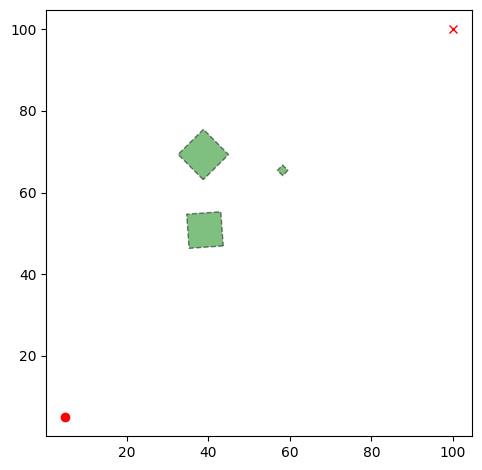

In [171]:
world = generate_world(
    {
        "start": (5.0, 5.0),
        "goal": (100.0, 100.0),
        "obstacles": {
            "number_of_squares": 3,
            "length_range": (1.0, 10.0),
            "theta_range": (0.0, 180.0),
            "x_range": (30.0, 70.0),
            "y_range": (30.0, 70.0),
        },
    }
)
draw_world(world)

## IV. Implement naive algorithm

Naive approach를 설명하는 것은 비트 낭비이리라.
아래와 같이 쉽게 구현할 수 있고, 결과를 그려보면 잘 구해진 것을 확인할 수 있다.

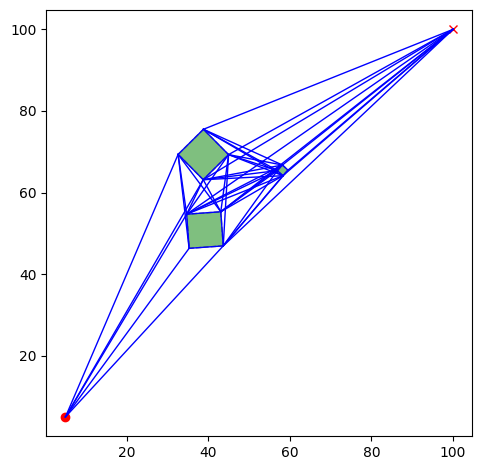

In [172]:
def construct_visibility_graph_naively(
    world: Dict[str, shapely.Geometry]
) -> List[shapely.LineString]:
    """Constructs a visibility graph using a naive algorithm.

    Args:
        world (Dict[str, shapely.Geometry]): World.
        e.g.,
        {
            "start"     : shapely.Point,
            "goal"      : shapely.Point,
            "obstacles" : shapely.MultiPolygon,
        }

    Returns:
        List[shapely.LineString]: Edges of the generated visibility graph.
    """
    points = [world["start"], world["goal"]]
    polygons = world["obstacles"]
    for polygon in polygons.geoms:
        points.extend([shapely.Point(point) for point in polygon.exterior.coords[:-1]])

    graph = []
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            ls = shapely.LineString((points[i], points[j]))
            if polygons.boundary.contains(ls) or ls.touches(polygons):
                graph.append(ls)

    return shapely.MultiLineString(graph)


draw_world(world, construct_visibility_graph_naively(world))

## V. Lee's approach

이제 본격적으로 효율적인 알고리즘에 대해 설명해보겠다.
이 알고리즘을 필자가 발견한 것은 DeBerg의 책이지만, 히스토리를 살펴보니 이 알고이즘은 D.T Lee 씨의 [dissertation](https://www.proquest.com/openview/d5156a89232a691e5534a148eabc9dc7/1?pq-origsite=gscholar&cbl=18750&diss=y)에서 제안되었다.
다만, D.T Lee 씨께서는 이 알고리즘이 그닥 대단한 것은 아니라고 여기셨는지 그냥 맥 없이 휙 지나가는 챕터 정도로 가볍게 다루었다.
~~이럴 때면 가끔씩 자괴감이...~~

D.T Lee 씨의 아이디어를 잘 이해하려면 알고리즘의 전체 구조를 top-down으로 살펴보는 것이 좋다.
적어도 필자는 이 편이 조금 더 이해가 수월했다.
효율적인 알고리즘의 얼개는 아래와 같다.

In [173]:
def construct_visibility_graph_efficiently(
    world: Dict[str, shapely.Geometry]
) -> List[shapely.LineString]:
    """Constructs a visibility graph using an efficient algorithm.
    This is a skeleton of the D.T Lee's algorithm.

    Args:
        world (Dict[str, shapely.Geometry]): World.
        e.g.,
        {
            "start"     : shapely.Point,
            "goal"      : shapely.Point,
            "obstacles" : shapely.MultiPolygon,
        }

    Returns:
        List[shapely.LineString]: Edges of the generated visibility graph.
    """
    graph = []
    polygons = world["obstacles"]
    graph.extend(construct_edges(world["start"], polygons).geoms)
    graph.extend(construct_edges(world["goal"], polygons).geoms)

    polygon_graph = build_polygon_graph(world["obstacles"])

    points = []
    for polygon in polygons.geoms:
        points.extend([shapely.Point(point) for point in polygon.exterior.coords[:-1]])

    for point in points:
        for q in get_visible_points(p, polygons, polygon_graph):
            graph.append(shapely.LineString((p, q)))

    return shapely.MultiLineString(graph)

위에서 밝힌 알고리즘의 얼개에는 아래 두 함수가 별 다른 설명이 없이 등장하였다.
이것에 대한 설명은 아래와 같다.

- `build_polygon_graph(polygons)`
  - 후술할 알고리즘은 특정한 점에 연결된 다각형 변을 쉽게 조회할 수 있어야하는 등 주어진 다각형 꼭지점의 연결관계를 관리해주어야 한다.
  - 이것이 뭐 대단한 일이겠냐만, 필자의 경우 `netwrokx` 패키지를 사용하여 그래프 형태로 관리하였다.
  - Visibility **graph**를 만들면서 단지 다각형 꼭지점의 연결관계를 나타내기 위하여 그래프를 사용하는 점이 독자에게 혼란을 줄까 걱정된다.
  - 그래도, (일단 내 블로그는 독자도 없을뿐더러) 이것을 사용함으로서 얻는 이득이 더 크다고 판단하여 이렇게 결정하였으니 독자의 너른 이해를 바란다.
- `construct_edges(p, polygons)`
  - 점 `p`에서부터 다각형 집합 `polygons`에 대해 보이는 꼭지점을 연결하는 그래프 간선들을 반횐한다.
  - 이것은 Lee's approach에서 다루고 있는 내용이 **아니다** (D.T Lee 씨는 시작점 및 도착점이 없는 문제를 풀었음).
  - 이 부분은 단지 필자가 start, goal을 다루기 위하여 추가한 코드이며 naive approach와 동일한 방법을 사용하여 구현하였다.
- `get_visible_points(p, polygons, polygon_graph)`: 점 `p`에서 다각형 집합 `polygons`에 대해 보이는 꼭지점들의 목록을 반환한다.
  - 이 함수가 바로 D.T Lee씨 논문의 main contribution 이며, 이 과정의 복잡도를 O(N^2) -> O(NlgN)으로 개선하였다.

### V.1. `build_polygon_graph(polygons)`

이 함수는 `networkx` 패키지를 사용해서 아래와 같이 간단하게 구현해줄 수 있다.

In [174]:
def build_polygon_graph(polygons: shapely.MultiPolygon) -> nx.Graph:
    """Builds a graph of which the vertices are points, and the edges are the sides.

    Args:
        polygons (shapely.MultiPolygon): Obstacles.

    Returns:
        nx.Graph: A graph representing the polygons.
    """
    id = 0
    graph = nx.Graph()
    for polygon in polygons.geoms:
        offset = id
        for i in range(len(polygon.exterior.coords) - 1):
            graph.add_node(id, id=id, coord=shapely.Point(polygon.exterior.coords[i]))
            id += 1
        for i in range(len(polygon.exterior.coords) - 2):
            graph.add_edge(offset + i, offset + i + 1)
        graph.add_edge(offset, offset + len(polygon.exterior.coords) - 2)
    return graph

### V.2. `construct_edges(p, polygons)`

앞서 말하였듯 `construct_edges(p, polygons)`는 딱히 언급할만한 내용이 없다 (naive approach와 크게 다르지 않으므로).
아래와 같이 코드만 보이고 넘어가도록 하겠다.

In [175]:
def construct_edges(
    p: shapely.Point, polygons: shapely.MultiPolygon
) -> shapely.MultiLineString:
    """Returns visibility graph edges spanning from `p`.

    Args:
        p (shapely.Point): Start or goal points.
        polygons (shapely.MultiPolygon): Obstacles.

    Returns:
        shapely.MultiLineString: Edges of the generated visibility graph.
    """
    graph = []
    for polygon in polygons.geoms:
        for q in polygon.exterior.coords[:-1]:
            ls = shapely.LineString((p, q))
            if ls.touches(polygons):
                graph.append(ls)
    return shapely.MultiLineString(graph)

### V.3. `get_visible_points(p, polygons)`

이제 이 포스팅의 주 목적이라고 할 수 있는 `get_visible_points(p, polygons)`의 효율적인 구현에 대해서 살펴보자.
몇 단계에 걸쳐 D.T Lee 씨의 아이디어를 소개할 것이다.

#### V.3.A. D.T Lee sweeps the plane using a half line in clockwise order

D.T Lee 는 반직선 (i.e. sweep line) 을 통해 평면을 시계 방향으로 sweep한다.
아래 예제는 이것이 무슨 말인지를 보여주고 있다.
`sweep-i`따위로 표현되고 이있는 반직선들이 바로 그것인데, 최초의 수평 방향 (positive-x 방향으로 뻗는) 반직선부터 시작하여 시계 방향으로 평면을 훝는 것을 알 수 있다.

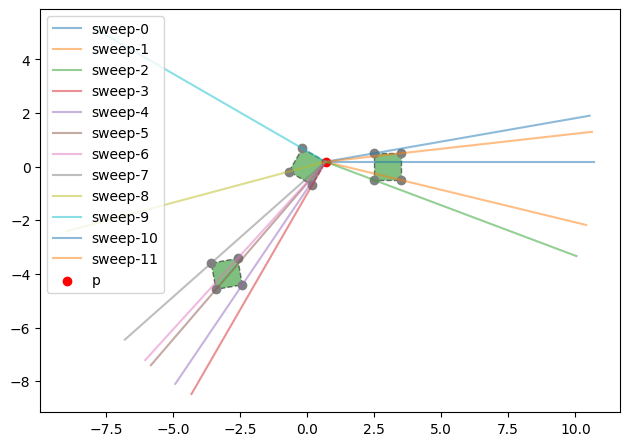

In [176]:
# DO NOT COPY THIS.
def scan_example(polygons):
    def my_atan2(p: shapely.Point, q: shapely.Point) -> float:
        theta = math.atan2(q.y - p.y, q.x - p.x)
        theta = -theta if theta < 0 else 2 * math.pi - theta
        return theta

    pts = []
    for polygon in polygons.geoms:
        pts.extend([shapely.Point(pt) for pt in polygon.exterior.coords[:-1]])
    p = pts[1]
    pts.sort(
        key=lambda q: (
            my_atan2(p, q),
            math.hypot(q.x - p.x, q.y - p.y),
        )
    )

    fig, ax = plt.subplots()
    for obstacle in polygons.geoms:
        ax.add_patch(
            patches.Polygon(
                obstacle.exterior.coords,
                fc="green",
                lw=1.0,
                color="black",
                ls="--",
                alpha=0.5,
            )
        )
    plt.plot([p.x, p.x + 10], [p.y, p.y], label="sweep-0", alpha=0.5)
    for i, q in enumerate(pts):
        if p == q:
            continue
        src = np.array([p.x, p.y])
        dst = np.array([q.x, q.y])
        dst = src + 10 * ((dst - src) / np.linalg.norm(dst - src))
        plt.plot([src[0], dst[0]], [src[1], dst[1]], label=f"sweep-{i+1}", alpha=0.5)
        plt.scatter(q.x, q.y, color="gray")

    plt.scatter(p.x, p.y, color="red", label="p")
    ax.set_aspect("equal")
    fig.tight_layout()
    plt.legend()
    plt.show()


fig_polygons = shapely.MultiPolygon(
    (
        rotate_and_translate(
            shapely.Polygon(((0.5, 0.5), (0.5, -0.5), (-0.5, -0.5), (-0.5, 0.5))),
            60,
            0,
            0,
        ),
        rotate_and_translate(
            shapely.Polygon(((0.5, 0.5), (0.5, -0.5), (-0.5, -0.5), (-0.5, 0.5))),
            0,
            3,
            0,
        ),
        rotate_and_translate(
            shapely.Polygon(((0.5, 0.5), (0.5, -0.5), (-0.5, -0.5), (-0.5, 0.5))),
            10,
            -3,
            -4,
        ),
    )
)

scan_example(fig_polygons)

#### V.3.B. D.T Lee manages `candidate_sides`

D.T Lee 씨는 위에서 밝힌 방법대로 평면을 sweep하며 `candidate_sides`라는 자료구조를 관리한다.
이 자료구조는 점 `p`에서 다각형 집합 `polygons`에 대해 보이는 꼭지점을 조사함에 있어 확인해 볼 가치가 있는 다각형의 변들을 의미한다.
반대로 이야기하면, `candidate_sides`에 속하지 않는 다각형의 변들은 확인해볼 필요가 없다.
대체 뭘 어떻게 관리하기에 이런 magic이 가능한 것인지, 관리 방법을 알아보도록 하자.

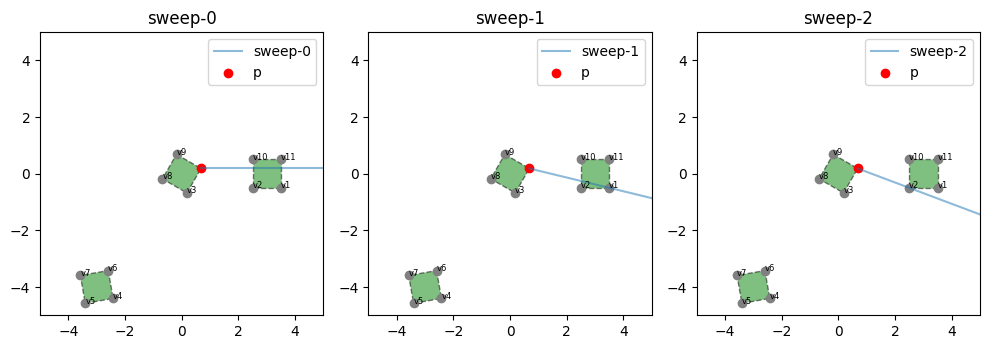

In [177]:
# DO NOT COPT THIS CODE BLOCK.
def candidate_sides_example(polygons):
    def my_atan2(p: shapely.Point, q: shapely.Point) -> float:
        theta = math.atan2(q.y - p.y, q.x - p.x)
        theta = -theta if theta < 0 else 2 * math.pi - theta
        return theta

    pts = []
    for polygon in polygons.geoms:
        pts.extend([shapely.Point(pt) for pt in polygon.exterior.coords[:-1]])
    p = pts[1]
    pts.sort(
        key=lambda q: (
            my_atan2(p, q),
            math.hypot(q.x - p.x, q.y - p.y),
        )
    )

    fig, ax = plt.subplots(1, 3, figsize=(10, 5))
    for obstacle in polygons.geoms:
        for i in range(3):
            ax[i].add_patch(
                patches.Polygon(
                    obstacle.exterior.coords,
                    fc="green",
                    lw=1.0,
                    color="black",
                    ls="--",
                    alpha=0.5,
                )
            )
    ax[0].plot([p.x, p.x + 10], [p.y, p.y], label="sweep-0", alpha=0.5)
    for i, q in enumerate(pts):
        if p == q:
            continue
        if i < 2:
            src = np.array([p.x, p.y])
            dst = np.array([q.x, q.y])
            dst = src + 10 * ((dst - src) / np.linalg.norm(dst - src))
            ax[i + 1].plot(
                [src[0], dst[0]], [src[1], dst[1]], label=f"sweep-{i+1}", alpha=0.5
            )
        for k in range(3):
            ax[k].scatter(q.x, q.y, color="gray")
            ax[k].text(q.x, q.y, f"v{i + 1}", fontsize=6)

    for i in range(3):
        ax[i].scatter(p.x, p.y, color="red", label="p")
        ax[i].set_aspect("equal")
        ax[i].set_xlim([-5, 5])
        ax[i].set_ylim([-5, 5])
        ax[i].legend()
        ax[i].set_title(f"sweep-{i}")
    fig.tight_layout()
    plt.show()


candidate_sides_example(fig_polygons)

위의 그림은 첫번째, 두번째, 그리고 세번째 sweeping을 보이고 있다 (이전 섹션에서 언급하였듯이 시계 방향으로 sweeping이 이뤄지고 있음).

`sweep-0`부터 살펴보자.
첫번째 sweep은 일종의 initial condition으로 볼 수 있는데, 아래의 과정을 통해 `candidate_sides`를 갱신해주면 된다.
`왜 이렇게 초기화하지?` 같은 의문이 드는 것이 당연할텐데, 조금만 참고 뒤의 내용을 읽어보기를 추천한다.
- positive-x 방향으로 뻗는 반직선이 교차하는 다각형의 변들을 찾아 `candidate_sides`에 추가한다.
- 단, 반직선과 다각형의 변이 변의 끝점에서 교차하는 경우에는 추가하지 않는다 (양쪽 어디이건 상관 없이).
그림의 예제에서는 `v2-v10`, `v1-v11` 이 추가될 것이다.

`sweep-1`을 살펴보자.
이 단계에서 해주어야 할 일은 아래와 같다.
- `candidate_sides`애 속한 변들과 sweep line이 교점을 갖는지 확인한다.
  - 교점이 있다면, `p`에서 `v1`은 보이지 않는다 (반대로 교점이 없다면 보는 것임).
- 교점의 획인이 끝나면, `v1`을 포함하는 두 변을 조사한다.
  - 두개의 변 중 sweep line을 기준으로 반시계 방향에 위치하는 변은 `candidate_sides`에서 삭제한다.
  - 두개의 변 중 sweep line을 기준으로 시계 방향에 위치하는 변은 `candidate_sides`에서 추가한다.
그림의 예제에서는 `sweep-1` 진행 시 `v1-v2`이 `candidate_sides`에 추가되고, `v1-v11` 이 `candidate_sides`에서 삭제된다.

{: .note }
> 왜 이렇게 하는 것일까?
> - `candidate_sides`애 속한 변들과 sweep line이 교점을 갖는다는 말은 sweep line p -> q 사이에 이 직선을 가로막는 다각형의 변이 있다는 이야기이고, 따라서 visible하지 못하다.
> - D.T Lee는 평면을 시계 방향으로 sweep하고 있으므로 sweep line을 기준으로 반시계 방향에 있었는 다각형의 변은 다음 점들을 조사할 때 영향을 미치지 못한다 (물론, 반바퀴 넘게 돌아서 다시 한 번 추가될 수 있음).

원활한 이해를 위해 동일하게 한 스텝 더 나아가 `sweep-2`를 살펴보자.
이 과정에서 `v2-10`, `v1-v2`이 `candidate_sides`에서 삭제된다.

#### V.3.C. D.T Lee implements `candidate_sides` as a binary tree

위의 예시에서 관찰할 수 있는 재미있는(?) 사실 중 하나는 sweep line과 교차하는 다각형의 변을 `candidate_sides`에서 찾을 때 굳이 모든 변들을 다 검사할 필요가 없다는 점이다.
만약 `candidate_sides`이 **이전** sweep line을 기준으로 교점 순서대로 사전에 정렬되어 있다면 우리는 그저 맨 앞의 다각형 변만을 검사해주면 된다.
여기서 "교점 순서"라는 것은 sweep line p->q에 대하여 p 에서 교점까지의 거리로 이해하면 된다.

다시 `sweep-0`으로 돌아가보자.
`v2-v10`, `v1-v11` 중 누가 더 sweep line과 먼저 교차하는가?
`v2-v10`이므로 `candidate_sides`에는 `v2-v10`가 `v1-v11`보다 먼저 저장된다.

이제 `sweep-1`으로 가보자.
다각형의 변들은 서로 교차 (꼭지점에서 만나는 것은 제외) 하지 않으므로 `sweep-0` 에서 만들어 놓은 순서는 세로운 변을 추가하기 전까지 유지될 것이다.
즉, 교점의 위치는 바뀌겠지만 교점 간의 위상은 변경되지 않는다는 이야기이다.
따라서, `v1`의 visibility를 판단할 떄는 sweep line과 `v2-v10` (`candidate_sides`의 가장 앞 원소)의 교차 여부만을 확인해주면 된다. 

여기까지 읽으면 스멀스멀 감이온다.
`candidate_sides`는 binary tree 형태로 관리하기 몹시 적절한 자료구조이다!
다만, 각 노드가 고정된 key 값을 갖지 않고, sweep line 상 교점의 위상을 기준으로 정렬되므로 구현이 은근히 까다롭다.
필자는 아래와 같이 구현하였다.

In [178]:
class Side:
    """A class representing a side of a polygon."""

    def __init__(self, src_id: int, dst_id: int, polygon_graph: nx.Graph):
        """C'tor.

        Args:
            src_id (int): ID of source vertex.
            dst_id (int): ID of destination vertex.
            polygon_graph (nx.Graph): A graph representing polygons.
        """
        if src_id > dst_id:
            self.__init__(dst_id, src_id)
            return
        self.src_id = src_id
        self.dst_id = dst_id
        self.side = shapely.LineString(
            (polygon_graph.nodes[src_id]["coord"], polygon_graph.nodes[dst_id]["coord"])
        )
        self.left = None
        self.right = None

    def is_equal(self, rhs: Self) -> bool:
        """Returns whether the `rhs` side is equals to self.

        Args:
            rhs (Self): A side.

        Returns:
            bool: True if self and the given side are equal.
        """
        return self.src_id == rhs.src_id and self.dst_id == rhs.dst_id

    def is_less_equal(self, sweep_line: shapely.LineString, rhs: Self) -> bool:
        """Returns whether self <= `rhs` on the given sweep line.

        Args:
            sweep_line (shapely.LineString): A sweep line.
            rhs (Self): A side.

        Returns:
            bool: Whether this <= `rhs` on the given sweep line.
        """
        start = sweep_line.coords[0]

        length_self = None
        for intersect in sweep_line.intersection(self.side).coords:
            length = np.hypot(intersect[0] - start[0], intersect[1] - start[1])
            length_self = (
                length if length_self is None or length < length_self else length_self
            )

        length_rhs = None
        for intersect in sweep_line.intersection(rhs.side).coords:
            length = np.hypot(intersect[0] - start[0], intersect[1] - start[1])
            length_rhs = (
                length if length_rhs is None or length < length_rhs else length_rhs
            )

        return length_self <= length_rhs

In [179]:
class CandidateSides:
    """A class for candidate sides."""

    def __init__(self):
        """C'tor."""
        self.root = None

    def get_min(self) -> Optional[Side]:
        """Gets the minimum side.

        Returns:
            Side: A minimum side.
        """
        return self._get_min(self.root)

    def _get_min(self, root: Optional[Side]) -> Optional[Side]:
        """Gets the minimum side from a tree rooted at `root`.

        Args:
            root (Optional[Side]): A root.

        Returns:
            Optional[Side]: A minimum side.
        """
        if root is None:
            return None
        elif root.left is not None:
            return self._get_min(root.left)
        else:
            return root

    def insert(self, sweep_line: shapely.LineString, side: Side) -> Side:
        """Inserts a side to the tree.

        Args:
            sweep_line (shapely.LineString): A sweep line.
            side (Side): A side to insert.

        Returns:
            Side: A root of inserted tree.
        """
        self.root = self._insert(sweep_line, self.root, side)
        return self.root

    def _insert(
        self, sweep_line: shapely.LineString, root: Optional[Side], side: Side
    ) -> Side:
        """Inserts a side to the tree.

        Args:
            sweep_line (shapely.LineString): A sweep line.
            root (Optional[Side]): A root.
            side (Side): A side to insert.

        Returns:
            Side: A root of inserted tree.
        """
        if root is None:
            root = side
        elif side.is_less_equal(sweep_line, root):
            root.left = self._insert(sweep_line, root.left, side)
        else:
            root.right = self._insert(sweep_line, root.right, side)
        return root

    def delete(self, sweep_line: shapely.LineString, side: Side) -> Optional[Side]:
        """Deletes a side from the tree.

        Args:
            sweep_line (shapely.LineString): A sweep line.
            side (Side): Side to delete.

        Returns:
            Optional[Side]: A root of deleted tree.
        """
        self.root = self._delete(sweep_line, self.root, side)
        return self.root

    def _delete(
        self, sweep_line: shapely.LineString, root: Optional[Side], side: Side
    ) -> Optional[Side]:
        """Deletes a side from the tree.

        Args:
            sweep_line (shapely.LineString): A sweep line.
            root (Optional[Side]): A root.
            side (Side): Side to delete.

        Returns:
            Optional[Side]: A root of deleted tree.
        """
        if root is None:
            return None
        elif root.is_equal(side):
            if root.left is None:
                return root.right
            elif root.right is None:
                return root.left
            else:
                min_side = self._get_min(root.right)
                root.src_id = min_side.src_id
                root.dst_id = min_side.dst_id
                root.side = min_side.side
                root.right = self._delete(sweep_line, root.right, min_side)
        elif side.is_less_equal(sweep_line, root):
            root.left = self._delete(sweep_line, root.left, side)
        else:
            root.right = self._delete(sweep_line, root.right, side)
        return root

    def traverse(self):
        """Inorder traverse."""
        self._traverse(self.root)
        print("\n")

    def _traverse(self, root: Optional[Side]):
        """Inorder traverse of the tree rooted at `root`,

        Args:
            root (Optional[Side]): A root.
        """
        if root is None:
            return
        self._traverse(root.left)
        print(f"({root.src_id}, {root.dst_id})")
        self._traverse(root.right)

#### V.2.D. Implement `get_visible_points(p, polygons, polygon_graph)`

이제 모든 준비물을 모아서 `get_visible_points(p, polygons)`를 구현하자.

In [180]:
def get_visible_points(
    p: shapely.Point, polygons: shapely.MultiPolygon, polygon_graph: nx.Graph
) -> shapely.MultiPoint:
    """Returns points that are visible from `p`.

    Args:
        p (shapely.Point): A point.
        polygons (shapely.MultiPolygon): Obstacles.
        polygon_graph (nx.Graph): A polygon graph.

    Returns:
        shapely.MultiPoint: Visible points.
    """
    max_extent = 1e6
    candidates = CandidateSides()
    sweep_line = shapely.LineString((p, (p.x + max_extent, p.y)))
    for src_id, dst_id in polygon_graph.edges:
        src = polygon_graph.nodes[src_id]["coord"]
        dst = polygon_graph.nodes[dst_id]["coord"]
        ls = shapely.LineString((src, dst))
        if sweep_line.crosses(ls):
            candidates.insert(sweep_line, Side(src_id, dst_id, polygon_graph))

    def my_atan2(p: shapely.Point, q: shapely.Point) -> float:
        theta = math.atan2(q.y - p.y, q.x - p.x)
        theta = -theta if theta < 0 else 2 * math.pi - theta
        return theta

    nodes = []
    for n in polygon_graph.nodes:
        if p != polygon_graph.nodes[n]["coord"]:
            nodes.append(polygon_graph.nodes[n])
    nodes.sort(
        key=lambda q: (
            my_atan2(p, q["coord"]),
            math.hypot(q["coord"].x - p.x, q["coord"].y - p.y),
        )
    )

    visible_points = []

    for node in nodes:
        min_side = candidates.get_min()
        if min_side is None or not min_side.side.intersects(sweep_line):
            visible_points.append(node["coord"])
        for neighbor in polygon_graph.neighbors(node["id"]):
            ls = shapely.LineString()





get_visible_points(
    shapely.Point((0, 0)), fig_polygons, build_polygon_graph(fig_polygons)
)

{'id': 5, 'coord': <POINT (3.5 -0.5)>}
{'id': 6, 'coord': <POINT (2.5 -0.5)>}
{'id': 2, 'coord': <POINT (0.183 -0.683)>}
{'id': 9, 'coord': <POINT (-2.421 -4.406)>}
{'id': 10, 'coord': <POINT (-3.406 -4.579)>}
{'id': 8, 'coord': <POINT (-2.594 -3.421)>}
{'id': 11, 'coord': <POINT (-3.579 -3.594)>}
{'id': 3, 'coord': <POINT (-0.683 -0.183)>}
{'id': 0, 'coord': <POINT (-0.183 0.683)>}
{'id': 1, 'coord': <POINT (0.683 0.183)>}
{'id': 7, 'coord': <POINT (2.5 0.5)>}
{'id': 4, 'coord': <POINT (3.5 0.5)>}
